### 1. Initialization

Imports and general parameters (from *parameters.py*).

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation_MOD as sim
import satellite_RFI.src.tools as tools  # <-- might not be necessary
import sys
sys.path.insert(0, './param_import/')
from imports import *
import parameters_graphs as pm


In [3]:
pm.show_parameters()

Block: 1551055211
Frequency range: 1100 - 1350 MHz


### 2. Figures from the article

#### 2.1 No Masking (+ global variables)

We start by retrieving the values; we can create a single simulation with the observations inside already defined (and the catalog retrieved etc), and then for each mask we just need to get the masking parameters and the ideal alphas found before (much quicker).

In [11]:
# we can use the same object throughout everything, only the mask changes
print("Simulating...", end=" ")
sat = sim.SatelliteSimulation(
        block=str(pm.block),
        use_data=True,
        path_data=pm.path_data,
        path_beam=pm.path_data,
        survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency],
        path_catalog=pm.path_catalog,
        beam_model=pm.beam_model,
        freq_range=[pm.fs, pm.fe],
        freq_slice=[pm.fs_slice, pm.fe_slice],
        time_slice=[None,None],
        include_cons=pm.include_cons,
        verbose=False,
    )
print("Done")

# these values are the same always
fs = sat.frequency[sat.ifreq[0]:sat.ifreq[1]]
ts = sat.nd_s0[sat.itime[0]:sat.itime[1]]
#N = len(sat.catalog["Alpha"])
N = 21  # <-- trial where the number of alphas is smaller than supposed to


Simulating... Done


In [12]:
# creating array of indexes necessary to broadcast (only need to compute it once)
sizes = np.diff(np.hstack([sat.index_sats, 286]))
index_alphas = []
n = 0
for i in range(len(sat.cons)):
    if (i!=0) and (sat.cons[i]!=sat.cons[i-1]):  n += sizes[i-1]
    index_alphas.extend(n + np.arange(sizes[i]))
order = np.array([0,1,2,3,9,10,11,12,18,19,20,4,5,6,7,8,13,14,15,16,17])  # <-- get the same order as before!


In [13]:
# storing values
alphas = []
simulations = []
CFs = []

for CF in ["C1","C2"]:
    # getting values
    print("Getting values for no mask and CF = {}.".format(CF))
    alphasi = pickle.load( open(pm.my_name(CF),'rb') )["best-fit"]
    sat.execute(alphasi[order][index_alphas])

    # saving values
    alphas.append(alphasi)
    simulations.append(np.ma.masked_equal(sat.simulation.T,0))
    if CF=="C1":  
        CFvalue = np.sum( ((sat.observations_sat-sat.simulation) / sat.observations)**2 )
    elif CF=="C2": 
        CFvalue = np.sum( (sat.observations_sat-sat.simulation)**2 )
    CFs.append( CFvalue / sat.simulation.size )
    

Getting values for no mask and CF = C1.
Getting values for no mask and CF = C2.


In [14]:
# ------------ PLOTTING FUNCTIONS (only for no mask) --------------- #

def plot_alphas_nomask(alphas):
    ''' Creates the plot of alpha values for C1 and C2. '''
    
    # plotting values
    fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)
    xs = np.arange(1, N + 1)
    ax.plot(xs, alphas[0], 'o', label=r'$\sigma_D=C_1$')
    ax.plot(xs, alphas[1], '*', label=r'$\sigma_D=C_2$')
    ax.axhline(0, color='black', linestyle='--')

    # creating figure
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(range(1, N + 1))
    ax.set_title(r'Block: {} No-Mask'.format(pm.block))
    ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
    ax.set_ylabel('Amplitude')
    ax.legend()
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_1d_nomask(simulations, CFs):
    ''' Creates the plots for 1d comparison between data and simulation, with background. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=True, sharey=True)
    fig.suptitle(r'Block: {} No-Mask'.format(pm.block))

    for i,CF in enumerate(["C_1","C_2"]):
        # plotting values
        ax = axs[i]
        ax.plot(fs, np.ma.mean(sat.observations_sat.T + sat.observations_BG.T, axis=0), label='Observation')
        ax.plot(fs, np.ma.mean(simulations[i] + sat.observations_BG.T, axis=0), '--', label='Simulation')
        
        # defining figure
        ax.set_ylabel('Temperature [K]')
        ax.set_xlabel('Frequency [MHz]')
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        textstr = "$\\sigma_{{D}}={}$\nFoM={:.2f}".format(CF,CFs[i])
        ax.text(0.685, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.legend(loc="upper left")

    # showing figure
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_2d_nomask(simulations):
    ''' Creates the plots for 1d comparison between data and simulation, with background. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=3, sharey=True)
    fig.suptitle(r'Block: {} No-Mask'.format(pm.block))  
    titles = ['Observation', r'$C_1$', r'$C_2$']
    
    for i,data in enumerate([sat.observations_sat.T, simulations[0], simulations[1]]):
        # plotting values
        ax = axs[i]
        default = sat.observations_sat.T + sat.observations_BG.T
        cax = ax.imshow(data + sat.observations_BG.T, aspect='auto', extent=[fs[0], fs[-1], ts[-1], ts[0]], 
                        vmax=np.max(default), vmin=np.min(default))

        # defining figure
        cbar = fig.colorbar(cax, ax=ax)
        cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
        ax.set_title(titles[i])
        ax.set_ylabel('Time [sec]')
        ax.set_xlabel('Frequency [MHz]')

    # showing figure
    fig.tight_layout()
    fig.show()
    

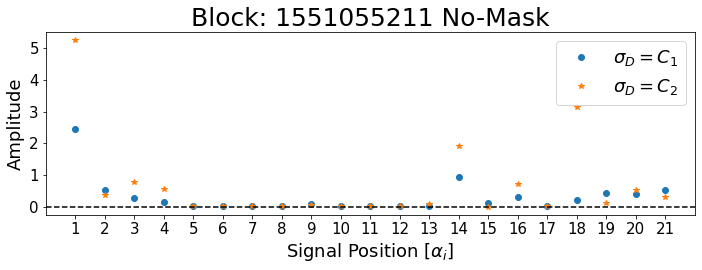

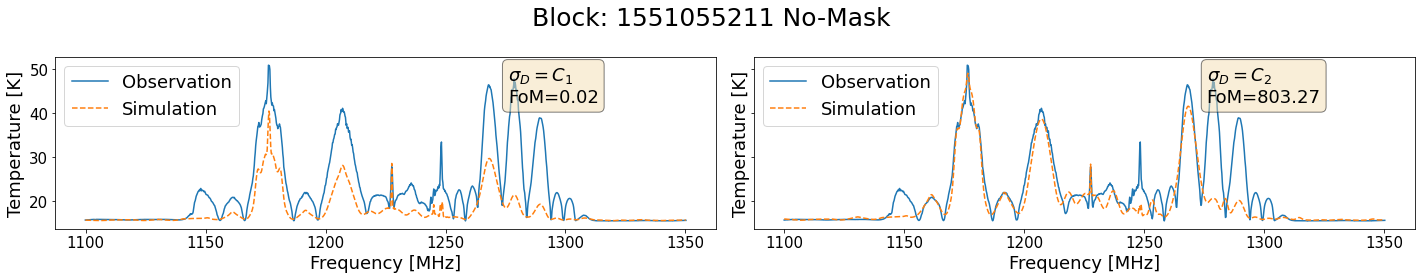

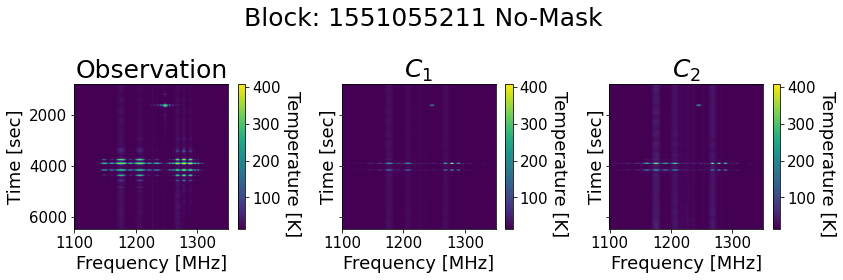

In [15]:
# plotting all things
plot_alphas_nomask(alphas)
plot_1d_nomask(simulations, CFs)
plot_2d_nomask(simulations)

#### 2.2 Angular masking

Now we create functions to display the plots, we use these ones for the rest of the masks.

In [16]:
# storing values
alphas = {}
simulations = {}
CFs = {}
observations = {}

for par in ["1F","5F"]:
    # creating mask
    path_nearby = pm.path_data + "nearby_satellites/nearby_satellite_close_angle_" + par + ".p"
    sat.create_mask(path_nearby=path_nearby, apply=False)
    observations[par] = np.ma.masked_equal(sat.observations_sat.T*sat.mask.T,0)
    Npoints = sat.mask[sat.mask].size

    for CF in ["C1","C2"]:
        # getting values
        print("Getting values for degree = {} and CF = {}.".format(par,CF))
        alphasi = pickle.load( open(pm.my_name(degree=par,CF_case=CF),'rb') )["best-fit"]
        sat.execute_withmask(alphasi[order][index_alphas])

        matrix = sat.observations_sat * sat.mask - sat.simulation
        if CF=="C1": 
            alphas[par] = [alphasi]
            simulations[par] = [np.ma.masked_equal(sat.simulation.T,0)]
            CFs[par] = [np.sum( (matrix / sat.observations)**2 ) / Npoints]
        elif CF=="C2":  
            alphas[par].append(alphasi)
            simulations[par].append(np.ma.masked_equal(sat.simulation.T,0))
            CFs[par].append(np.sum( matrix**2 ) / Npoints)


Getting values for degree = 1F and CF = C1.
Getting values for degree = 1F and CF = C2.
Getting values for degree = 5F and CF = C1.
Getting values for degree = 5F and CF = C2.


In [17]:
## ----- PLOTTING FUNCTIONS (the same for the rest of the plots) ----- ##

def plot_alphas(alphas, labels_mask, title):
    ''' Creates the plot of alpha values for C1 and C2. '''

    # creating figures
    points = ['o', '*', 'x', '.', 'o']
    fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=True)

    # plotting values
    xs = np.arange(1, N + 1)
    for i,label in enumerate(labels_mask):
        axs[0].plot(xs, alphas[label][0], points[i], label="{}: {}".format(title,label))
        axs[1].plot(xs, alphas[label][1], points[i], label="{}: {}".format(title,label))

    # showing figure
    fig.suptitle(r'Block: {} {} Mask'.format(pm.block,title))
    for i,CF in enumerate(["C_1","C_2"]):
        ax = axs[i]
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_xticks(range(1, N + 1))
        ax.set_ylabel('Amplitude')
        textstr = r"$\sigma_D={}$".format(CF)
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.axhline(0, color='black', linestyle='--')
        ax.legend()
    axs[1].set_xlabel(r'Signal Position $[\alpha_{i}]$')
    
    fig.tight_layout()
    fig.show()

# ----------------------------------- #

def plot_1d(observations, simulations, CFs, labels_mask, title):
    ''' Creates the plots for 1d comparison between data and simulation. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 3*len(labels_mask)), nrows=len(labels_mask), ncols=2, sharey=True)
    fig.suptitle(r'Block {}, {} Mask'.format(pm.block, title))

    for iCF,CF in enumerate(["C_1","C_2"]):
        for ilabel,label in enumerate(labels_mask):
            
            # plotting values
            ax = axs[ilabel,iCF]
            ax.plot(fs, np.ma.mean(observations[label]+sat.observations_BG.T, axis=0), label='Observation')
            ax.plot(fs, np.ma.mean(simulations[label][iCF]+sat.observations_BG.T, axis=0), '--', label='Simulation')

            # defining figure
            textstr = "$\\sigma_D={}$\n{}={}\nFoM$={:.3f}$".format(CF,title,label,CFs[label][iCF])
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
            if ilabel==1:  ax.set_xlabel('Frequency [MHz]')
            ax.set_ylabel('Temperature [K]')
            ax.legend(loc='upper right')

    # showing figure
    fig.tight_layout()
    fig.show()

# ----------------------------------- #

def plot_2d(observations, simulations, labels_mask, title):
    ''' Creates the plots for 2d comparison between data and simulation. ''' 

    # creating figures
    super_titles = ['Observation', r'$C_1$', r'$C_2$']
    fig,axs = plt.subplots(figsize=(16,3+2*len(labels_mask)), nrows=len(labels_mask), ncols=3,
                           sharey=True, sharex=True)
    fig.suptitle("Block {}, {} Mask".format(pm.block, title))

    for ilabel,label in enumerate(labels_mask):
        for idata,data in enumerate([observations[label], simulations[label][0], simulations[label][1]]):
            # plotting values
            ax = axs[ilabel,idata]
            default = observations[label] + sat.observations_BG.T
            cax = ax.imshow(data + sat.observations_BG.T, aspect='auto', extent=[fs[0],fs[-1],ts[-1],ts[0]], 
                            vmax=np.max(default), vmin=np.ma.min(default))
    
            # defining figure
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            ax.set_title(super_titles[idata])
            ax.set_ylabel('Time [sec]')
            ax.set_xlabel('Frequency [MHz]')

    # showing figure
    fig.tight_layout()
    fig.show()
    

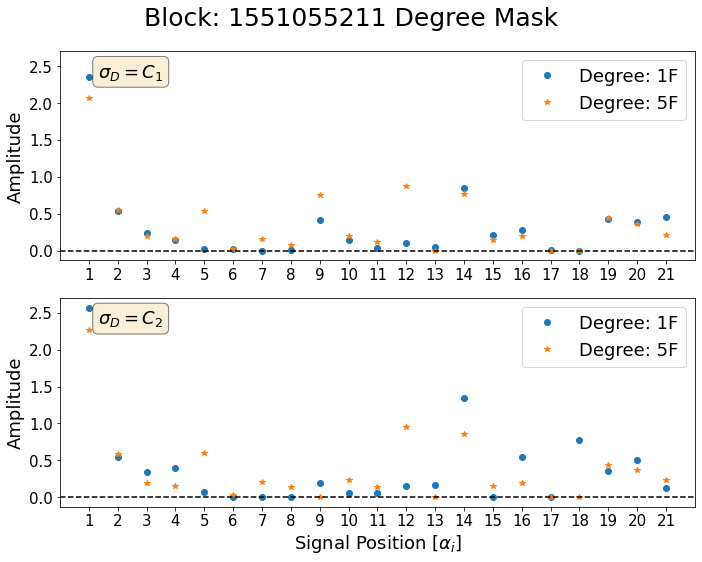

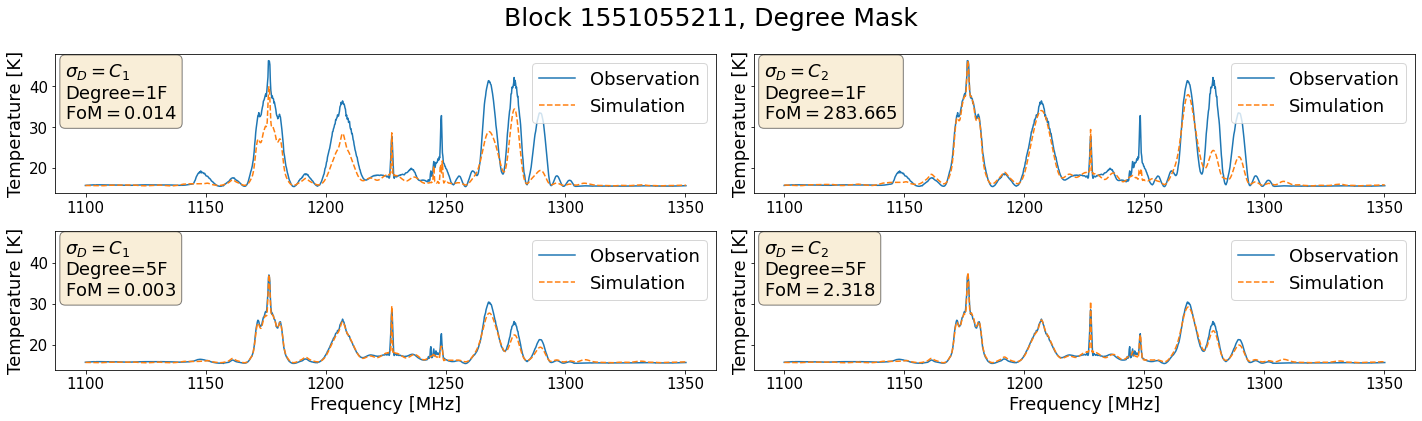

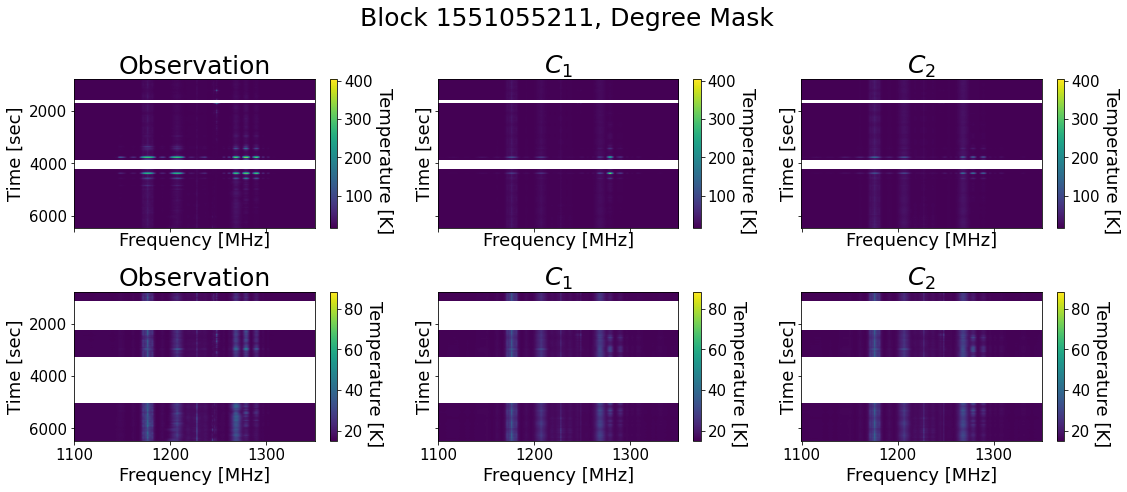

In [18]:
# showing plots
labels_mask = ["1F","5F"]
title = "Degree"
plot_alphas(alphas, ["1F","5F"], "Degree")
plot_1d(observations, simulations, CFs, labels_mask, title)
plot_2d(observations, simulations, labels_mask, title)

#### 2.3 Thermal masking

In [20]:
# storing values
alphas = {}
simulations = {}
CFs = {}
observations = {}

for par in [25,50,100]:
    # creating mask
    sat.create_mask(temperature=par, apply=False)
    observations[par] = np.ma.masked_equal(sat.observations_sat.T*sat.mask.T,0)
    Npoints = sat.mask[sat.mask].size

    for CF in ["C1","C2"]:
        # getting values
        print("Getting values for temperature = {} and CF = {}.".format(par,CF))
        alphasi = pickle.load( open(pm.my_name(temperature=par,CF_case=CF),'rb') )["best-fit"]
        sat.execute_withmask(alphasi[order][index_alphas])

        matrix = sat.observations_sat * sat.mask - sat.simulation
        if CF=="C1": 
            alphas[par] = [alphasi]
            simulations[par] = [np.ma.masked_equal(sat.simulation.T,0)]
            CFs[par] = [np.sum( (matrix / sat.observations)**2 ) / Npoints]
        elif CF=="C2":  
            alphas[par].append(alphasi)
            simulations[par].append(np.ma.masked_equal(sat.simulation.T,0))
            CFs[par].append(np.sum( matrix**2 ) / Npoints)


Getting values for temperature = 25 and CF = C1.
Getting values for temperature = 25 and CF = C2.
Getting values for temperature = 50 and CF = C1.
Getting values for temperature = 50 and CF = C2.
Getting values for temperature = 100 and CF = C1.
Getting values for temperature = 100 and CF = C2.


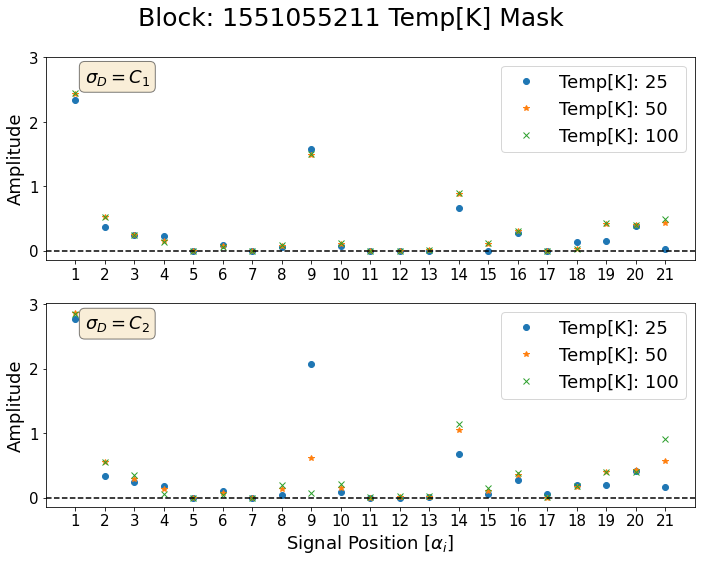

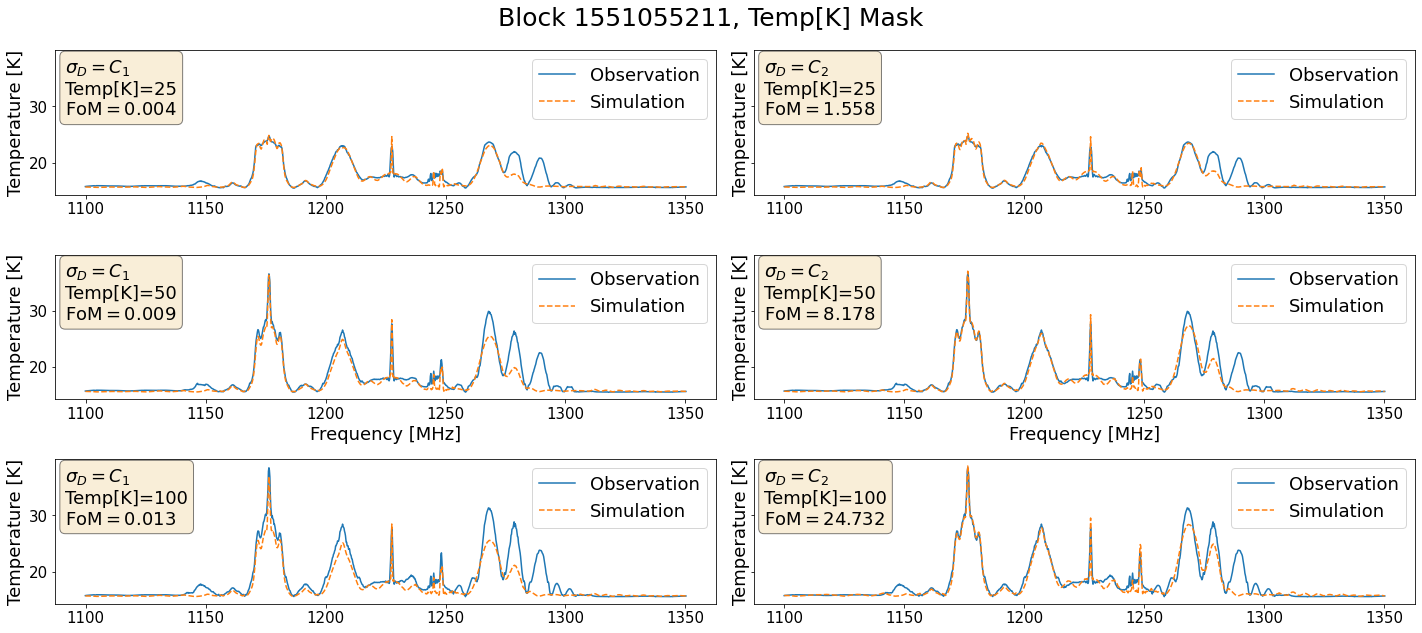

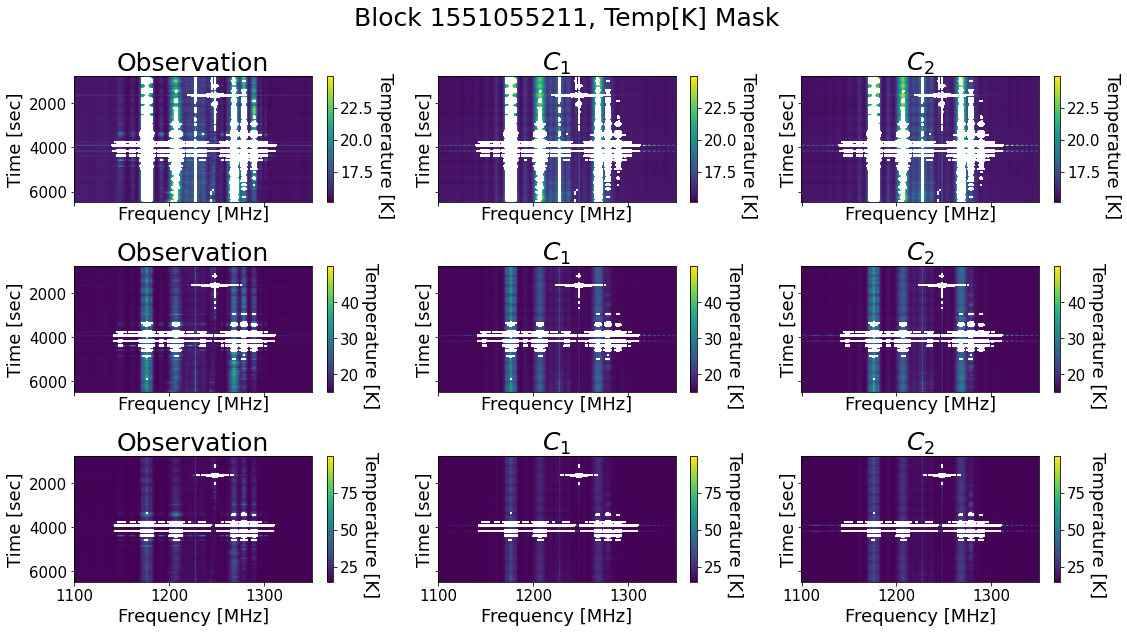

In [21]:
# showing plots
labels_mask = [25,50,100]
title = "Temp[K]"
plot_alphas(alphas, labels_mask, title)
plot_1d(observations, simulations, CFs, labels_mask, title)
plot_2d(observations, simulations, labels_mask, title)

#### 3.4 Pixel-timeline Masking

In [23]:
# storing values
alphas = {}
simulations = {}
CFs = {}
observations = {}

for par in [2,5,7]:
    # creating mask
    sat.create_mask(pix=par, apply=False)
    observations[par] = np.ma.masked_equal(sat.observations_sat.T*sat.mask.T,0)
    Npoints = sat.mask[sat.mask].size

    for CF in ["C1","C2"]:
        # getting values
        print("Getting values for timeline temperature = {} and CF = {}.".format(par,CF))
        alphasi = pickle.load( open(pm.my_name(pix=par,CF_case=CF),'rb') )["best-fit"]
        sat.execute_withmask(alphasi[order][index_alphas])

        matrix = sat.observations_sat * sat.mask - sat.simulation
        if CF=="C1": 
            alphas[par] = [alphasi]
            simulations[par] = [np.ma.masked_equal(sat.simulation.T,0)]
            CFs[par] = [np.sum( (matrix / sat.observations)**2 ) / Npoints]
        elif CF=="C2":  
            alphas[par].append(alphasi)
            simulations[par].append(np.ma.masked_equal(sat.simulation.T,0))
            CFs[par].append(np.sum( matrix**2 ) / Npoints)


Getting values for timeline temperature = 2 and CF = C1.
Getting values for timeline temperature = 2 and CF = C2.
Getting values for timeline temperature = 5 and CF = C1.
Getting values for timeline temperature = 5 and CF = C2.
Getting values for timeline temperature = 7 and CF = C1.
Getting values for timeline temperature = 7 and CF = C2.


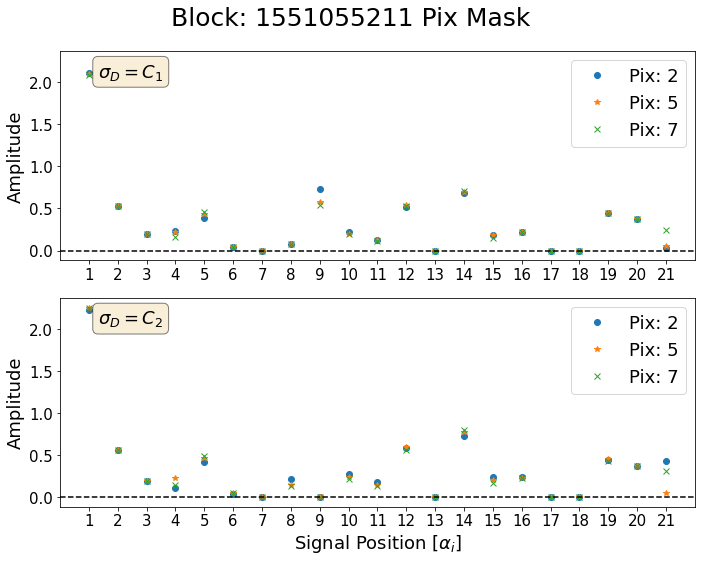

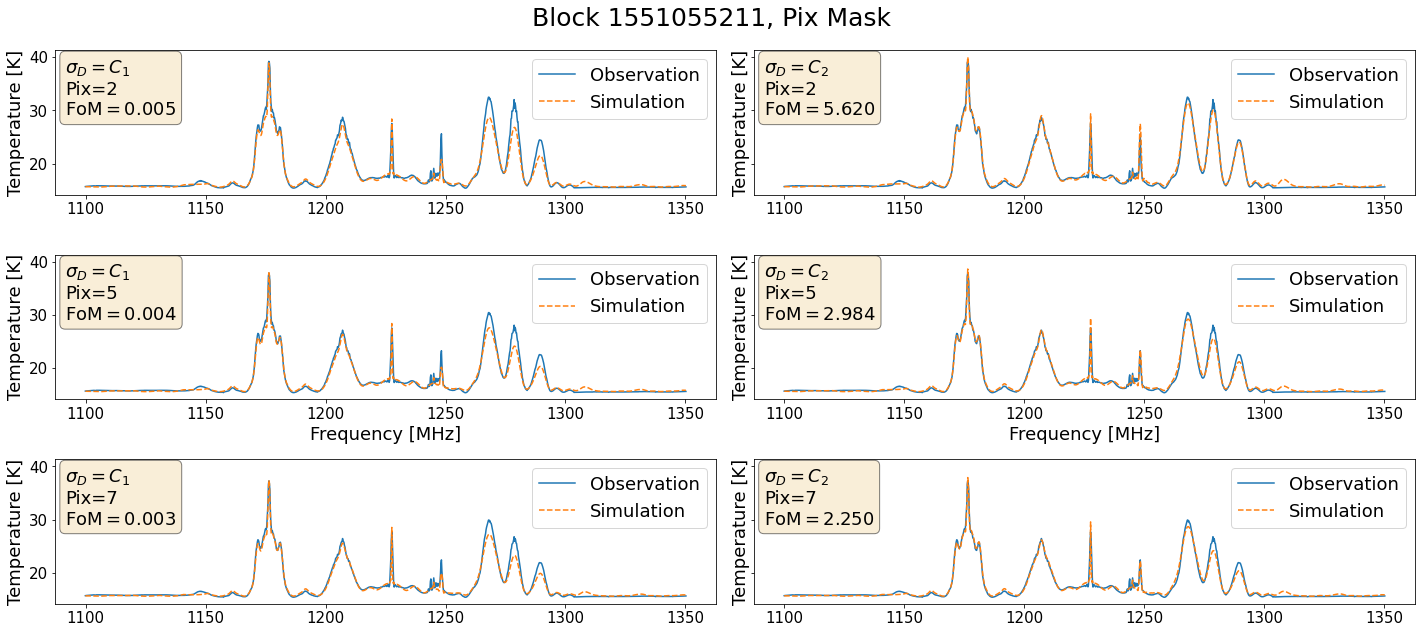

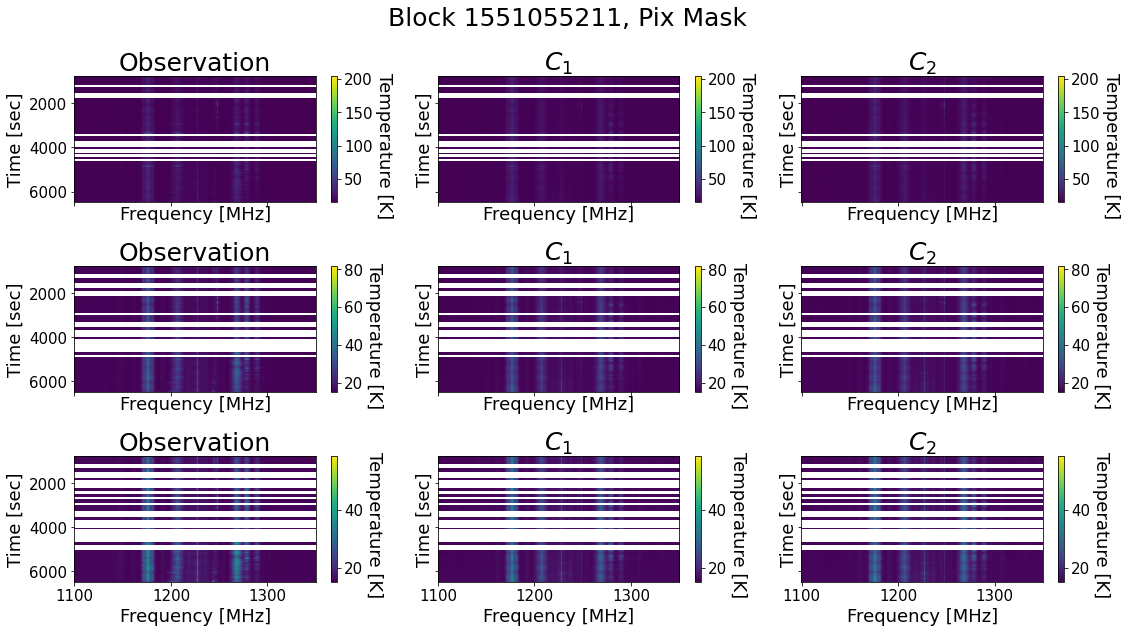

In [24]:
# showing plots
labels_mask = [2,5,7]
title = "Pix"
plot_alphas(alphas, labels_mask, title)
plot_1d(observations, simulations, CFs, labels_mask, title)
plot_2d(observations, simulations, labels_mask, title)

#### 3.5 Time slicing

POR FAZER!